# Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import lightgbm as lgb
import geopandas as gpd

from shapely.geometry import Point
from scipy.optimize import minimize
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from math import radians, sin, cos, sqrt, atan2
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans

from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0


# Load Dataset and Cleaning

parse data test supaya kolomnya jadi datetime/nama_pos/id dari yang awalnya cmn id doang

In [2]:
# 1. Load raw files
train = pd.read_csv('../data/train.csv', parse_dates=['datetime'])
test_raw = pd.read_csv('../data/test.csv')
env = pd.read_csv('../data/data_pendukung/data_lingkungan.csv', parse_dates=['datetime'])
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')

# 2. Parse kolom 'id' di test.csv -> jadi 'datetime' dan 'nama_pos'
# format id: "2025-09-19 06:00:00 - Arjowinangun - Pacitan"
# split hanya di kemunculan PERTAMA " - " (karena nama pos bisa mengandung " - " juga)
split_result = test_raw['id'].str.split(' - ', n=1, expand=True)
test = pd.DataFrame({
    'datetime': pd.to_datetime(split_result[0]),
    'nama_pos': split_result[1],
    'id': test_raw['id']   # simpan buat submission nanti
})

# test.to_csv("test_tes.csv", index=False)

print(test['nama_pos'].nunique())  # pastikan tetap 30
print(test.head())

30
             datetime                nama_pos  \
0 2025-09-19 06:00:00  Arjowinangun - Pacitan   
1 2025-09-19 12:00:00  Arjowinangun - Pacitan   
2 2025-09-19 18:00:00  Arjowinangun - Pacitan   
3 2025-09-20 06:00:00  Arjowinangun - Pacitan   
4 2025-09-20 12:00:00  Arjowinangun - Pacitan   

                                             id  
0  2025-09-19 06:00:00 - Arjowinangun - Pacitan  
1  2025-09-19 12:00:00 - Arjowinangun - Pacitan  
2  2025-09-19 18:00:00 - Arjowinangun - Pacitan  
3  2025-09-20 06:00:00 - Arjowinangun - Pacitan  
4  2025-09-20 12:00:00 - Arjowinangun - Pacitan  


gabung semua dataset train dan test untuk persiapan aggregation kolom dengan data lingkungan

In [3]:
train['is_train'] = 1
test['is_train'] = 0
test['tma_mdpl'] = np.nan   # kosongkan target, akan diisi model nanti

full = pd.concat([
    train[['datetime', 'nama_pos', 'tma_mdpl', 'is_train']],
    test[['datetime', 'nama_pos', 'tma_mdpl', 'is_train', 'id']]
], ignore_index=True, sort=False)

full = full.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
print(full.shape)   # harus = 84396 + 21780
full.head()

# full.to_csv("full_data.csv",index=False)

(106176, 5)


,datetime,nama_pos,tma_mdpl,is_train,id
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30,1,NaN
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20,1,NaN
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50,1,NaN
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45,1,NaN
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25,1,NaN


gabungkan data lingkungan ke data fullnya (+ cleaned dari -999 di solar radiation)

In [4]:
full = pd.read_csv('../data/full_data.csv', parse_dates=['datetime'])
env = pd.read_csv('../data/data_pendukung/data_lingkungan.csv', parse_dates=['datetime'])

# === LANGKAH BARU: bersihkan sentinel -999 SEBELUM agregasi ===
numeric_cols = env.select_dtypes(include='number').columns
for col in numeric_cols:
    n_sentinel = (env[col] == -999).sum()
    if n_sentinel > 0:
        print(f'{col}: {n_sentinel} baris sentinel -999 -> diubah jadi NaN')
        env[col] = env[col].replace(-999, np.nan)

# === LANGKAH LAMA: assign window_end (tidak berubah) ===
hour = env['datetime'].dt.hour
date = env['datetime'].dt.normalize()
conditions = [hour < 6, hour < 12, hour < 18]
choices = [date + pd.Timedelta(hours=6), date + pd.Timedelta(hours=12), date + pd.Timedelta(hours=18)]
default = date + pd.Timedelta(days=1, hours=6)
env['window_end'] = np.select(conditions, choices, default=default)

# === LANGKAH LAMA: agregasi (tidak berubah, tapi hasilnya sekarang aman krn NaN otomatis di-skip oleh sum/mean) ===
agg_dict = {
    'rainfall_mm': 'sum', 'rainfall_openmeteo_mm': 'sum', 'rainfall_max_24h_mm': 'max',
    'humidity_pct': 'mean', 'wind_direction_deg': 'mean', 'dew_point_c': 'mean',
    'cloud_cover_pct': 'mean', 'temperature_c': 'mean', 'wind_speed_kmh': 'mean',
    'solar_radiation_mj_m2': 'sum', 'soil_moisture_0_7cm': 'mean', 'soil_moisture_7_28cm': 'mean',
    'soil_moisture_28_100cm': 'mean', 'soil_moisture_100_255cm': 'mean',
    'surface_pressure_hpa': 'mean', 'pressure_msl_hpa': 'mean', 'built_surface_m2': 'first',
    'landcover_class': 'first', 'landcover_name': 'first', 'rmm1': 'mean', 'rmm2': 'mean',
    'mjo_phase': 'first', 'mjo_amplitude': 'mean', 'mjo_active': 'first', 'nino_34': 'mean',
}
env_agg = env.groupby(['nama_pos', 'window_end']).agg(agg_dict).reset_index()

sum_cols = ['rainfall_mm', 'rainfall_openmeteo_mm', 'solar_radiation_mj_m2']

for col in sum_cols:
    all_nan_mask = env.groupby(['nama_pos', 'window_end'])[col].apply(lambda x: x.isna().all())
    n_affected = all_nan_mask.sum()
    print(f'{col}: {n_affected} window full-NaN -> override balik jadi NaN')
    # all_nan_mask index-nya sama (nama_pos, window_end) dgn env_agg, jadi bisa langsung dipakai buat masking
    env_agg.loc[all_nan_mask.values, col] = np.nan
    
env_agg = env_agg.rename(columns={'window_end': 'datetime'})

full = full.merge(env_agg, on=['nama_pos', 'datetime'], how='left')

# === CEK HASIL ===
print(full['solar_radiation_mj_m2'].describe())   # min sekarang harusnya wajar, tidak lagi -11988
print(full[full['datetime'] >= '2025-12-31'][['solar_radiation_mj_m2','soil_moisture_0_7cm','nino_34']].isna().sum())

# full.to_csv("../data/full_data_merged.csv",index=False)

solar_radiation_mj_m2: 100080 baris sentinel -999 -> diubah jadi NaN
rainfall_mm: 0 window full-NaN -> override balik jadi NaN
rainfall_openmeteo_mm: 0 window full-NaN -> override balik jadi NaN
solar_radiation_mj_m2: 12510 window full-NaN -> override balik jadi NaN
count    93696.000000
mean      1719.582734
std       1338.502936
min          0.000000
25%         14.120000
50%       2084.360000
75%       2836.980000
max       4387.940000
Name: solar_radiation_mj_m2, dtype: float64
solar_radiation_mj_m2    12480
soil_moisture_0_7cm         60
nino_34                   1590
dtype: int64


In [5]:
print("""
    note: pada tgl 4 feb - 28 feb 2025 itu gaada datanya jadi abis 3 feb langsung ke 1 maret 2025, ntar bakal di bring up
    di preprocessing

""")


    note: pada tgl 4 feb - 28 feb 2025 itu gaada datanya jadi abis 3 feb langsung ke 1 maret 2025, ntar bakal di bring up
    di preprocessing




## feature engineering

### check dataset gabungan

In [6]:
full.head()

,datetime,nama_pos,tma_mdpl,is_train,id,rainfall_mm,rainfall_openmeteo_mm,rainfall_max_24h_mm,humidity_pct,wind_direction_deg,...,pressure_msl_hpa,built_surface_m2,landcover_class,landcover_name,rmm1,rmm2,mjo_phase,mjo_amplitude,mjo_active,nino_34
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30,1,NaN,0.0,0.0,0.0,86.000000,348.333333,...,1009.066667,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20,1,NaN,0.3,0.3,0.2,79.166667,327.666667,...,1010.800000,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50,1,NaN,3.6,3.6,1.7,81.666667,296.333333,...,1008.983333,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45,1,NaN,1.0,1.0,1.7,90.250000,316.166667,...,1010.000000,2419.0,10,Tree cover,-0.311643,1.335574,7.0,1.386106,1.0,-0.72
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25,1,NaN,0.6,0.6,1.7,79.500000,298.166667,...,1010.766667,2419.0,10,Tree cover,-0.530987,1.393549,7.0,1.491283,1.0,-0.72


### dropping columns

In [7]:
full.drop([
    "rainfall_openmeteo_mm", # korelasi = 1
], axis=1, inplace=True)

In [8]:
river = gpd.read_file("../data/data_pendukung/HydroRIVERS_v10_au_shp/HydroRIVERS_v10_au.shp")
river = river.to_crs(4326)

print(river.columns)

Index(['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM',
       'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS',
       'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'geometry'],
      dtype='object')


### detect glitches

In [9]:
full = pd.read_csv('../data/full_data_merged.csv', parse_dates=['datetime'])
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')

def detect_and_fix_glitches(df, window=4, ratio_threshold=4, zscore_threshold=10, min_abs_jump=1.0):
    df = df.sort_values(['nama_pos','datetime'])  # TANPA reset_index (biar index tetap nyambung ke full)
    glitch_indices = []
    for pos, g in df.groupby('nama_pos'):
        val = g['tma_mdpl'].values
        idx_list = g.index.tolist()
        local_std = np.std(val)
        for i in range(window, len(val)-window):
            neighborhood = np.concatenate([val[i-window:i], val[i+1:i+1+window]])
            local_median = np.median(neighborhood)
            cur_v = val[i]
            jump = abs(cur_v - local_median)
            if jump < min_abs_jump:
                continue
            ratio = max(cur_v/local_median, local_median/cur_v) if cur_v>0 and local_median>0 else 999
            is_extreme = (ratio > ratio_threshold) or (local_std > 0 and (jump/local_std) > zscore_threshold)
            if is_extreme:
                glitch_indices.append(idx_list[i])
    print(f'Ditemukan {len(glitch_indices)} titik glitch')
    df.loc[glitch_indices, 'tma_mdpl'] = np.nan
    df['tma_mdpl'] = df.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.interpolate(method='linear'))
    return df, glitch_indices

train_part = full[full['is_train']==1].copy()
train_part_fixed, glitch_idx = detect_and_fix_glitches(train_part)
full.loc[train_part_fixed.index, 'tma_mdpl'] = train_part_fixed['tma_mdpl']

Ditemukan 24 titik glitch


### adding features

In [69]:
# full, feature_cols = add_feature.add_features(full, koor)
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')

full.drop(['rainfall_openmeteo_mm'], axis=1, inplace=True, errors="ignore")
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== reindex grid 6-jaman (msh perlu, krn rain/soil_moisture lag-roll butuh alignment waktu) =====
grids = []
for pos, g in full.groupby('nama_pos'):
    full_range = pd.date_range(g['datetime'].min(), g['datetime'].max(), freq='6h')
    full_range = full_range[full_range.hour.isin([6,12,18])]
    grids.append(pd.DataFrame({'nama_pos': pos, 'datetime': full_range}))
grid = pd.concat(grids, ignore_index=True)
full = grid.merge(full, on=['nama_pos','datetime'], how='left')
full['is_phantom'] = full['is_train'].isna().astype(int)
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== FITUR WAKTU (lebih lengkap) =====
full['hour'] = full['datetime'].dt.hour
full['day'] = full['datetime'].dt.day
full['month'] = full['datetime'].dt.month
full['week'] = full['datetime'].dt.isocalendar().week.astype(int)
full['quarter'] = full['datetime'].dt.quarter
full['dayofyear'] = full['datetime'].dt.dayofyear
full['dayofweek'] = full['datetime'].dt.dayofweek
full['is_weekend'] = full['dayofweek'].isin([5,6]).astype(int)
full['hour_sin'] = np.sin(2*np.pi*full['hour']/24)
full['hour_cos'] = np.cos(2*np.pi*full['hour']/24)
full['month_sin'] = np.sin(2*np.pi*full['month']/12)
full['month_cos'] = np.cos(2*np.pi*full['month']/12)
full['dayofyear_sin'] = np.sin(2*np.pi*full['dayofyear']/365)
full['dayofyear_cos'] = np.cos(2*np.pi*full['dayofyear']/365)

# ===== FITUR CUACA: lag & rolling (SEMUA berbasis cuaca, BUKAN target -> gak butuh recursion) =====
g = full.groupby('nama_pos')

def rollsum(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).sum())
def rollmean(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).mean())

full['rainfall_mm_lag_1'] = g['rainfall_mm'].shift(1)
full['rainfall_mm_lag_3'] = g['rainfall_mm'].shift(3)
full['rainfall_mm_lag_6'] = g['rainfall_mm'].shift(6)
full['humidity_lag_1'] = g['humidity_pct'].shift(1)
full['soil_moisture_0_7cm_lag_1'] = g['soil_moisture_0_7cm'].shift(1)
full['soil_moisture_7_28cm_lag_1'] = g['soil_moisture_7_28cm'].shift(1)
full['soil_moisture_28_100cm_lag_1'] = g['soil_moisture_28_100cm'].shift(1)
full['soil_moisture_100_255cm_lag_1'] = g['soil_moisture_100_255cm'].shift(1)

full['rainfall_mm_roll_sum_6'] = rollsum('rainfall_mm', 6)
full['rainfall_mm_roll_sum_12'] = rollsum('rainfall_mm', 12)
full['soil_moisture_0_7cm_roll_mean_6'] = rollmean('soil_moisture_0_7cm', 6)
full['soil_moisture_7_28cm_roll_mean_6'] = rollmean('soil_moisture_7_28cm', 6)
full['soil_moisture_28_100cm_roll_mean_6'] = rollmean('soil_moisture_28_100cm', 6)
full['soil_moisture_100_255cm_roll_mean_6'] = rollmean('soil_moisture_100_255cm', 6)

# akumulasi hujan multi-window (48h=8 periode, 96h=16, 144h=24, 168h=28, 336h=56 -- satuan 6 jam-an)
full['rain_cumsum_48h']  = rollsum('rainfall_mm', 8)
full['rain_cumsum_96h']  = rollsum('rainfall_mm', 16)
full['rain_cumsum_144h'] = rollsum('rainfall_mm', 24)
full['rain_cumsum_168h'] = rollsum('rainfall_mm', 28)
full['rain_cumsum_336h'] = rollsum('rainfall_mm', 56)

# indeks iklim: rolling mean jangka panjang (120 & 240 periode 6-jaman = ~30 & ~60 hari)
for col in ['rmm1','rmm2','mjo_amplitude','nino_34']:
    full[f'{col}_roll_mean_120'] = rollmean(col, 120)
    full[f'{col}_roll_mean_240'] = rollmean(col, 240)

full['delta_rain_1'] = g['rainfall_mm'].diff(1)
full['delta_pressure_1'] = g['surface_pressure_hpa'].diff(1)

# =========================================================
# SHOCK / INTENSITY FEATURES
# =========================================================

# lag tambahan (2 hari, 3 hari, 4 hari)
full['rainfall_mm_lag_8']  = g['rainfall_mm'].shift(8)
full['rainfall_mm_lag_12'] = g['rainfall_mm'].shift(12)
full['rainfall_mm_lag_16'] = g['rainfall_mm'].shift(16)

# rolling pendek (lebih responsif)
full['rain_roll_sum_2'] = rollsum('rainfall_mm', 2)
full['rain_roll_sum_4'] = rollsum('rainfall_mm', 4)

# rolling rata-rata pendek
full['rain_roll_mean_2'] = rollmean('rainfall_mm', 2)
full['rain_roll_mean_4'] = rollmean('rainfall_mm', 4)

# maksimum hujan terakhir
full['rain_roll_max_4'] = g['rainfall_mm'].transform(
    lambda x: x.shift(1).rolling(4).max()
)

full['rain_roll_max_8'] = g['rainfall_mm'].transform(
    lambda x: x.shift(1).rolling(8).max()
)

# intensitas hujan
full['rain_intensity'] = (
    full['rainfall_mm'] /
    (full['rainfall_mm_roll_sum_12'] + 1)
)

# perubahan hujan
full['delta_rain_3'] = g['rainfall_mm'].diff(3)
full['delta_rain_6'] = g['rainfall_mm'].diff(6)

# perubahan soil moisture
full['delta_sm_0_7'] = g['soil_moisture_0_7cm'].diff(1)
full['delta_sm_7_28'] = g['soil_moisture_7_28cm'].diff(1)

# interaksi hujan × kelembapan tanah
full['rain_x_soil'] = (
    full['rainfall_mm'] *
    full['soil_moisture_0_7cm']
)

# interaksi hujan × humidity
full['rain_x_humidity'] = (
    full['rainfall_mm'] *
    full['humidity_pct']
)

# end of shock

full['wind_dir_sin'] = np.sin(np.radians(full['wind_direction_deg']))
full['wind_dir_cos'] = np.cos(np.radians(full['wind_direction_deg']))

# new features

# Rolling STD
def rollstd(col, n):
    return g[col].transform(lambda x: x.shift(1).rolling(n).std())

full["rain_roll_std_4"] = rollstd("rainfall_mm",4)
full["rain_roll_std_8"] = rollstd("rainfall_mm",8)

full["sm_roll_std_4"] = rollstd("soil_moisture_0_7cm",4)

# Rolling MAX soil moisture

full["sm_max_4"] = g["soil_moisture_0_7cm"].transform(
    lambda x:x.shift(1).rolling(4).max()
)

full["sm_max_8"] = g["soil_moisture_0_7cm"].transform(
    lambda x:x.shift(1).rolling(8).max()
)

# Rain anomaly

full["rain_anomaly"] = (
    full["rainfall_mm"] - full["rain_roll_mean_4"]
)

# Rain acceleration

full["rain_acceleration"] = (
    full["delta_rain_1"] - full["delta_rain_3"]
)


# Rain × Climate

full["rain_x_nino"] = (
    full["rainfall_mm"] * full["nino_34"]
)

full["rain_x_mjo"] = (
    full["rainfall_mm"] * full["mjo_amplitude"]
)

# Soil saturation ratio

full["soil_saturation"] = (
    full["soil_moisture_0_7cm"] / (full["soil_moisture_100_255cm"] + 1e-6)
)

# Soil anomaly

full["sm_anomaly"] = (
    full["soil_moisture_0_7cm"] - full["soil_moisture_0_7cm_roll_mean_6"]
)

# Rolling median

full["rain_roll_median_4"] = g["rainfall_mm"].transform(
    lambda x:x.shift(1).rolling(4).median()
)

# =========================================================
# Raining Features
# =========================================================

# API

# def api(series, k=0.9):
#     out = np.zeros(len(series))
#     for i in range(1,len(series)):
#         if np.isnan(series.iloc[i-1]):
#             rain = 0
#         else:
#             rain = series.iloc[i-1]

#         out[i] = rain + k*out[i-1]

#     return out

# full["api"] = (
#     g["rainfall_mm"]
#     .transform(api)
# )

# # Rain duration

# def consecutive_rain(x):

#     out=[]
#     c=0

#     for r in x:

#         if pd.isna(r):
#             out.append(np.nan)

#         elif r>0:

#             c+=1
#             out.append(c)

#         else:

#             c=0
#             out.append(0)

#     return pd.Series(out,index=x.index)

# full["rain_duration"] = (
#     g["rainfall_mm"]
#     .transform(consecutive_rain)
# )

# # Heavy Rain indicator

# thr = full["rainfall_mm"].quantile(0.95)

# full["heavy_rain"] = (
#     full["rainfall_mm"] > thr
# ).astype(int)

# # Fraction short vs long rain

# full["recent_rain_ratio"] = (
#     full["rain_roll_sum_2"] /
#     (full["rainfall_mm_roll_sum_12"]+1)
# )

# # Rain Persistence

# full["rain_events_4"] = (
#     g["rainfall_mm"]
#     .transform(
#         lambda x:
#         x.shift(1)
#         .rolling(4)
#         .apply(lambda y:(y>0).sum())
#     )
# )

full['doy_sin'] = np.sin(2*np.pi*full['datetime'].dt.dayofyear/365.25)
full['doy_cos'] = np.cos(2*np.pi*full['datetime'].dt.dayofyear/365.25)
# opsional: harmonik orde-2 buat pola lebih kompleks
full['doy_sin2'] = np.sin(4*np.pi*full['datetime'].dt.dayofyear/365.25)
full['doy_cos2'] = np.cos(4*np.pi*full['datetime'].dt.dayofyear/365.25)


# ===== buang phantom, gabung lokasi =====
full = full[full['is_phantom']==0].drop(columns=['is_phantom']).reset_index(drop=True)
full = full.merge(koor, on='nama_pos', how='left')

# ===== FITUR STASIUN STATIS (KUNCI: gantikan tma_lag tanpa butuh recursion) =====
train_mask = full['is_train']==1
station_stats = full[train_mask].groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
full = full.merge(station_stats, on='nama_pos', how='left')

# ===== nearest_station_dist (haversine, dari koordinat) =====
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

pos_coords = koor.set_index('nama_pos')[['latitude','longitude']]
nearest_dist = {p1: min(haversine(*pos_coords.loc[p1], *pos_coords.loc[p2])
                        for p2 in pos_coords.index if p2 != p1)
                for p1 in pos_coords.index}
full['nearest_station_dist'] = full['nama_pos'].map(nearest_dist)

# ===== encoding kategorikal =====
from sklearn.preprocessing import LabelEncoder
for col in ['nama_pos','landcover_name','mjo_phase','mjo_active']:
    le = LabelEncoder()
    full[col+'_enc'] = le.fit_transform(full[col].astype(str))

train = full[full['is_train']==1].copy()
test = full[full['is_train']==0].copy()
non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
feature_cols = [c for c in train.columns if c not in non_feature]
print(train.shape, test.shape, len(feature_cols), 'fitur')

(84396, 132) (21780, 132) 124 fitur


In [71]:
def add_decayed_persistence(base_actual_df, target_df, decay_days=90, is_training=False, seed=42):
    rng = np.random.default_rng(seed)
    hist = base_actual_df[['nama_pos','datetime','tma_mdpl']].sort_values('datetime').copy()
    tgt = target_df.sort_values('datetime').copy()

    if is_training:
        # hitung berapa hari histori yg BENERAN ada sebelum tiap baris (per stasiun)
        start_per_pos = hist.groupby('nama_pos')['datetime'].transform('min')
        # gabung biar tiap baris tgt tau start histori stasiunnya
        start_map = hist.groupby('nama_pos')['datetime'].min()
        tgt['_start_hist'] = tgt['nama_pos'].map(start_map)
        max_lookback = (tgt['datetime'] - tgt['_start_hist']).dt.days.clip(lower=1)
        # horizon acak, TAPI dibatasi max_lookback (gak boleh nembus sebelum data mulai)
        rand_horizon = rng.integers(1, 400, size=len(tgt))
        capped_horizon = np.minimum(rand_horizon, max_lookback.values)
        tgt['lookup_date'] = tgt['datetime'] - pd.to_timedelta(capped_horizon, unit='D')
        tgt = tgt.drop(columns=['_start_hist'])
    else:
        last_map = hist.groupby('nama_pos')['datetime'].max()
        tgt['lookup_date'] = tgt['nama_pos'].map(last_map)

    out_parts = []
    for pos, g in tgt.groupby('nama_pos'):
        h = hist[hist['nama_pos']==pos].sort_values('datetime')
        if len(h)==0:
            g['anchor_value']=np.nan; g['anchor_date']=pd.NaT
            out_parts.append(g); continue
        g2 = pd.merge_asof(g.sort_values('lookup_date'), h[['datetime','tma_mdpl']].rename(
                columns={'datetime':'anchor_date','tma_mdpl':'anchor_value'}),
                left_on='lookup_date', right_on='anchor_date', direction='backward')
        out_parts.append(g2)

    res = pd.concat(out_parts).sort_index()
    res['days_since_anchor'] = (res['datetime'] - res['anchor_date']).dt.days.clip(lower=0)
    res['decayed_persistence'] = res['anchor_value'] * np.exp(-res['days_since_anchor']/decay_days)

    # fallback kalau masih ada NaN (stasiun baru muncul dll) -> netral, gak asal 0
    fallback = res['anchor_value'].median()
    res['decayed_persistence'] = res['decayed_persistence'].fillna(fallback)

    return res.drop(columns=['lookup_date','anchor_date','anchor_value','days_since_anchor'], errors='ignore')

In [72]:
pairs = [
    ('Bengkelolor','Boboh Kali Lamong',1.6), ('Brangkal','Bojonegoro - Kali Kethek',5.4),
    ('Gunungsari','Arjowinangun - Pacitan',6.7), ('Jarum','Serenan',7.8),
    ('Kali Pepe - Tugu Boto','Kali Anyar - Kreteg Abang',8.3), ('Ketonggo','Napel',8.8),
    ('Ngadipiro','Wonogiri Dam',10.8), ('Karangnongko','Cepu',18.8), ('Colo Weir','Serenan',19.5),
    ('Napel','Karangnongko',23.8), ('Sumberrejo','Babat',24.0), ('Floodway Bridge C','Karanggeneng',26.8),
    ('Ngrembang','Wonogiri Dam',26.9), ('Kali Anyar - Kreteg Abang','Kedungupit',28.0),
    ('Wonogiri Dam','Serenan',30.1), ('Jurug','Kedungupit',30.2), ('Kedungupit','Kajangan',31.8),
    ('Kali Pepe - PTPN','Kedungupit',32.8), ('Kajangan','Napel',34.9), ('Peren','Kedungupit',43.2),
    ('Serenan','Kedungupit',44.7), ('Babat','Karanggeneng',48.1), ('Bojonegoro - Kali Kethek','Babat',51.7),
    ('Cepu','Bojonegoro - Kali Kethek',59.5), ('Sekayu','Napel',66.9), ('Badegan','Napel',79.0),
]

velocity_kmh = 3.6  # asumsi ~1 m/s, khas sungai dataran rendah spt Bengawan Solo
pairs_calibrated = []
for up, down, dist_km in pairs:
    delay_hours = dist_km / velocity_kmh
    lag_steps = max(0, round(delay_hours / 6))   # bulatkan ke kelipatan 6 jam
    pairs_calibrated.append((up, down, lag_steps))
    print(f'{up} -> {down}: jarak={dist_km}km, delay~{delay_hours:.1f}jam, lag_steps={lag_steps}')

Bengkelolor -> Boboh Kali Lamong: jarak=1.6km, delay~0.4jam, lag_steps=0
Brangkal -> Bojonegoro - Kali Kethek: jarak=5.4km, delay~1.5jam, lag_steps=0
Gunungsari -> Arjowinangun - Pacitan: jarak=6.7km, delay~1.9jam, lag_steps=0
Jarum -> Serenan: jarak=7.8km, delay~2.2jam, lag_steps=0
Kali Pepe - Tugu Boto -> Kali Anyar - Kreteg Abang: jarak=8.3km, delay~2.3jam, lag_steps=0
Ketonggo -> Napel: jarak=8.8km, delay~2.4jam, lag_steps=0
Ngadipiro -> Wonogiri Dam: jarak=10.8km, delay~3.0jam, lag_steps=0
Karangnongko -> Cepu: jarak=18.8km, delay~5.2jam, lag_steps=1
Colo Weir -> Serenan: jarak=19.5km, delay~5.4jam, lag_steps=1
Napel -> Karangnongko: jarak=23.8km, delay~6.6jam, lag_steps=1
Sumberrejo -> Babat: jarak=24.0km, delay~6.7jam, lag_steps=1
Floodway Bridge C -> Karanggeneng: jarak=26.8km, delay~7.4jam, lag_steps=1
Ngrembang -> Wonogiri Dam: jarak=26.9km, delay~7.5jam, lag_steps=1
Kali Anyar - Kreteg Abang -> Kedungupit: jarak=28.0km, delay~7.8jam, lag_steps=1
Wonogiri Dam -> Serenan: jara

In [73]:
def add_upstream_feature(df, pairs_calibrated, value_lookup_fn):
    """
    df               : dataframe target (train_set/va/test) yg mau ditambah fitur
    pairs_calibrated : list (upstream, downstream, lag_steps)
    value_lookup_fn(nama_pos, datetime) -> nilai TMA (asli ATAU hasil prediksi, tergantung konteks)
    """
    df = df.copy()
    df['upstream_tma'] = np.nan
    for up, down, lag_steps in pairs_calibrated:
        mask = df['nama_pos'] == down
        lookup_time = df.loc[mask, 'datetime'] - pd.Timedelta(hours=6*lag_steps)
        df.loc[mask, 'upstream_tma'] = [value_lookup_fn(up, t) for t in lookup_time]
    # fallback netral kalau gak ketemu upstream / gak ada datanya
    df['upstream_tma'] = df['upstream_tma'].fillna(df.groupby('nama_pos')['tma_mdpl'].transform('median')
                                                     if 'tma_mdpl' in df.columns else df['upstream_tma'].median())
    return df

In [74]:
river = gpd.read_file("../data/data_pendukung/HydroRIVERS_v10_au_shp/HydroRIVERS_v10_au.shp")
river = river.to_crs(4326)

river_centroids = river.geometry.centroid
river_coords = np.column_stack([river_centroids.x.values, river_centroids.y.values])
station_coords = koor[['longitude','latitude']].values

tree = cKDTree(river_coords)
_, idx = tree.query(station_coords, k=1)

koor_hydro = koor.copy()
koor_hydro['upstream_area'] = river.iloc[idx]['UPLAND_SKM'].values
print(koor_hydro[['nama_pos','upstream_area']])

C:\Users\leouw\AppData\Local\Temp\ipykernel_11056\3215790450.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  river_centroids = river.geometry.centroid


                     nama_pos  upstream_area
0                    Ketonggo         3746.1
1                      Sekayu          800.9
2                        Cepu        10926.8
3                Karanggeneng           41.5
4    Bojonegoro - Kali Kethek        12778.1
5                     Badegan          244.3
6                       Lorog           47.6
7                Wonogiri Dam         1344.7
8                    Kajangan         5492.4
9           Boboh Kali Lamong          617.2
10  Kali Anyar - Kreteg Abang          426.7
11                  Colo Weir            3.6
12                  Ngadipiro          377.5
13                Bengkelolor            4.9
14                  Ngrembang          138.8
15               Karangnongko        10032.6
16      Kali Pepe - Tugu Boto           24.9
17                 Kedungupit         4711.0
18                   Brangkal          801.6
19           Kali Pepe - PTPN            7.0
20                      Babat        14342.2
21        

In [75]:
coords_arr = koor_hydro[['latitude','longitude']].values
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)   # coba n_clusters beda2: 3, 5, 8
koor_hydro['station_cluster'] = kmeans.fit_predict(coords_arr)
print(koor_hydro[['nama_pos','station_cluster']].sort_values('station_cluster'))

                     nama_pos  station_cluster
3                Karanggeneng                0
9           Boboh Kali Lamong                0
13                Bengkelolor                0
27          Floodway Bridge C                0
10  Kali Anyar - Kreteg Abang                1
11                  Colo Weir                1
16      Kali Pepe - Tugu Boto                1
7                Wonogiri Dam                1
23                      Jurug                1
24                      Jarum                1
29                    Serenan                1
22                      Peren                1
17                 Kedungupit                1
19           Kali Pepe - PTPN                1
4    Bojonegoro - Kali Kethek                2
18                   Brangkal                2
26                 Sumberrejo                2
20                      Babat                2
1                      Sekayu                3
25                 Gunungsari                3
5            

In [76]:
train_only = full[full["is_train"] == 1].copy()

station_mean = (
    train_only
    .groupby("nama_pos")["tma_mdpl"]
    .mean()
)

global_mean = train_only["tma_mdpl"].mean()

full["nama_pos_te"] = (
    full["nama_pos"]
    .map(station_mean)
    .fillna(global_mean)
)

In [77]:
full['musim_hujan'] = full['month'].isin([11,12,1,2,3]).astype(int)
full['is_dam'] = (full['nama_pos'] == 'Wonogiri Dam').astype(int)
full['dayofyear_sin_x_dam'] = full['dayofyear_sin'] * full['is_dam']
full['dayofyear_cos_x_dam'] = full['dayofyear_cos'] * full['is_dam']

In [83]:
full = full.merge(koor_hydro[['nama_pos','upstream_area','station_cluster']], on='nama_pos', how='left')

full['rain_x_upstream']     = full['rainfall_mm']       * full['upstream_area']
full['rain_48h_x_upstream'] = full['rain_cumsum_48h']    * full['upstream_area']
full['rain_7d_x_upstream']  = full['rain_cumsum_168h']   * full['upstream_area']
full['rain_14d_x_upstream'] = full['rain_cumsum_336h']   * full['upstream_area']

## finalize before split train and val

balikin train ke train dan test ke test dari full, remove non feature columns

In [84]:
# jalankan setelah full['musim_hujan'] dibuat
train = full[full['is_train']==1].copy()
test  = full[full['is_train']==0].copy()

non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
print(train.shape, test.shape)

(84396, 136) (21780, 136)


In [85]:
# full.to_csv("full.csv", index=False)

In [86]:
train.head()

,nama_pos,datetime,tma_mdpl,is_train,id,rainfall_mm,rainfall_max_24h_mm,humidity_pct,wind_direction_deg,dew_point_c,...,doy_cos2,latitude_y,longitude_y,station_mean_tma_y,station_min_tma_y,station_max_tma_y,upstream_area_y,station_cluster_y,upstream_area,station_cluster
0,Arjowinangun - Pacitan,2023-01-01 06:00:00,1.30,1.0,NaN,0.0,0.0,86.000000,348.333333,22.466667,...,0.999408,-8.197561,111.114314,1.116478,0.347639,4.85,650.6,3,650.6,3
1,Arjowinangun - Pacitan,2023-01-01 12:00:00,1.20,1.0,NaN,0.3,0.2,79.166667,327.666667,23.550000,...,0.999408,-8.197561,111.114314,1.116478,0.347639,4.85,650.6,3,650.6,3
2,Arjowinangun - Pacitan,2023-01-01 18:00:00,1.50,1.0,NaN,3.6,1.7,81.666667,296.333333,24.050000,...,0.999408,-8.197561,111.114314,1.116478,0.347639,4.85,650.6,3,650.6,3
3,Arjowinangun - Pacitan,2023-01-02 06:00:00,1.45,1.0,NaN,1.0,1.7,90.250000,316.166667,23.316667,...,0.997634,-8.197561,111.114314,1.116478,0.347639,4.85,650.6,3,650.6,3
4,Arjowinangun - Pacitan,2023-01-02 12:00:00,1.25,1.0,NaN,0.6,1.7,79.500000,298.166667,23.333333,...,0.997634,-8.197561,111.114314,1.116478,0.347639,4.85,650.6,3,650.6,3


## split data train val

In [87]:
cutoff = pd.Timestamp('2025-03-03')  # ~80% waktu pertama utk train, 20% terakhir utk val

train_set = train[train['datetime'] < cutoff].copy()
val_set = train[train['datetime'] >= cutoff].copy()

print(train_set.shape, val_set.shape)
print('train_set:', train_set['datetime'].min(), '-', train_set['datetime'].max())
print('val_set:', val_set['datetime'].min(), '-', val_set['datetime'].max())
# pastikan semua 30 pos ada di kedua set
print('pos di train_set:', train_set['nama_pos'].nunique(), '| pos di val_set:', val_set['nama_pos'].nunique())

(66441, 136) (17955, 136)
train_set: 2023-01-01 06:00:00 - 2025-03-02 18:00:00
val_set: 2025-03-03 06:00:00 - 2025-09-18 18:00:00
pos di train_set: 30 | pos di val_set: 30


In [88]:
stats = train_set.groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
te = train_set.groupby('nama_pos')['tma_mdpl'].mean()
gmean = train_set['tma_mdpl'].mean()

drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
train_set = train_set.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
val_set = val_set.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
train_set['nama_pos_te'] = train_set['nama_pos'].map(te).fillna(gmean)
val_set['nama_pos_te'] = val_set['nama_pos'].map(te).fillna(gmean)

# Modelling

In [89]:
feature_cols = [c for c in train.columns if c not in non_feature]
# extra_feats = ['decayed_persistence']
# extra_feats = ['upstream_tma', 'decayed_persistence']
# extra_feats = ['upstream_tma']
# feature_cols += [f for f in extra_feats if f not in feature_cols]

cutoff = pd.Timestamp('2025-03-03')
train_set = train[train['datetime'] < cutoff].copy()
val_set = train[train['datetime'] >= cutoff].copy()

cutoffs = [
    ('2023-11-01','2024-05-01'),
    ('2024-05-01','2024-11-01'),
    ('2024-11-01','2025-05-01'),
]

xgb_params  = dict(n_estimators=350,  learning_rate=0.04, max_depth=6,
                    subsample=0.7, colsample_bytree=0.8, random_state=42)
lgbm_params = dict(n_estimators=2000, learning_rate=0.04, max_depth=6,
                    subsample=0.8, colsample_bytree=0.7, random_state=42, verbosity=-1)
cat_params  = dict(iterations=300,  learning_rate=0.04, depth=6,
                    subsample=0.8, colsample_bylevel=0.8, random_state=42, verbose=False)

In [90]:
# low_importance_drop = [
#     'rain_acceleration', 'wind_speed_kmh', 'pressure_msl_hpa', 'wind_direction_deg',
#     'mjo_phase_enc', 'delta_sm_7_28', 'delta_sm_0_7', 'rain_x_humidity',
#     'temperature_c', 'sm_anomaly', 'rainfall_mm_lag_16', 'is_weekend',
#     'rain_x_mjo', 'rain_intensity', 'humidity_pct', 'rain_roll_sum_4',
#     'rainfall_mm_lag_8', 'delta_rain_1', 'rain_x_soil', 'hour_sin',
#     'hour_cos', 'hour', 'mjo_active_enc'
# ]

# feature_cols = [c for c in feature_cols if c not in low_importance_drop]
# print(f'{len(feature_cols)}')

### XGBoost

In [ ]:
# xgb = XGBRegressor(**xgb_params)
# sample_weight_tr = np.where(train_set['musim_hujan']==1, 10, 1.0)
# xgb.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_tr)

# pred_val_xgb = xgb.predict(val_set[feature_cols])
# rmse_xgb = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_xgb))
# print(f'RMSE XGBoost (single split): {rmse_xgb:.4f}')

In [92]:
# results_xgb = []
# for train_end, val_end in cutoffs:
#     tr = train[train['datetime'] < train_end]
#     va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]

#     stats = tr.groupby('nama_pos')['tma_mdpl'].agg(
#         station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
#     te = tr.groupby('nama_pos')['tma_mdpl'].mean()
#     gmean = tr['tma_mdpl'].mean()
#     gmin = tr['tma_mdpl'].min()
#     gmax = tr['tma_mdpl'].max()

#     drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
#     tr = tr.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')
#     va = va.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')

#     tr['nama_pos_te'] = tr['nama_pos'].map(te).fillna(gmean)
#     va['nama_pos_te'] = va['nama_pos'].map(te).fillna(gmean)

#     sample_weight_tr = np.where(tr['musim_hujan']==1, 10, 1.0)
#     # TAMBAHAN INI — biar gak NaN kalau ada stasiun baru yang belum ada histori:
#     for col, fallback in [('station_mean_tma', gmean), ('station_min_tma', gmin), ('station_max_tma', gmax)]:
#         tr[col] = tr[col].fillna(fallback)
#         va[col] = va[col].fillna(fallback)

    
#     model = XGBRegressor(**xgb_params)   # ganti model sesuai cell
#     model.fit(tr[feature_cols], tr['tma_mdpl'], sample_weight=sample_weight_tr)
#     pred = model.predict(va[feature_cols])
#     rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
#     results_xgb.append(rmse)
#     print(f'Fold RMSE: {rmse:.4f}')
# print(f'RMSE CV rata-rata: {np.mean(results_xgb):.4f} +/- {np.std(results_xgb):.4f}')

In [93]:
# print(f'RMSE CV rata-rata: {np.mean(results_xgb):.4f} +/- {np.std(results_xgb):.4f}')

## LGBM

In [ ]:
# lgbm = LGBMRegressor(**lgbm_params)
# sample_weight_tr = np.where(train_set['musim_hujan']==1, 8.2, 1.0)
# lgbm.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_tr)

# pred_val_lgbm = lgbm.predict(val_set[feature_cols])
# rmse_lgbm = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_lgbm))
# print(f'RMSE LightGBM (single split): {rmse_lgbm:.4f}')

In [95]:
# results_lgbm = []
# all_pred = []
# for train_end, val_end in cutoffs:
#     tr = train[train['datetime'] < train_end]
#     va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]

#     stats = tr.groupby('nama_pos')['tma_mdpl'].agg(
#         station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
#     te = tr.groupby('nama_pos')['tma_mdpl'].mean()
#     gmean = tr['tma_mdpl'].mean()

#     drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
#     tr = tr.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')
#     va = va.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')
#     tr['nama_pos_te'] = tr['nama_pos'].map(te).fillna(gmean)
#     va['nama_pos_te'] = va['nama_pos'].map(te).fillna(gmean)
    
#     sample_weight_tr = np.where(tr['musim_hujan']==1, 8.2, 1.0)

#     model = LGBMRegressor(**lgbm_params)   # ganti model sesuai cell
#     model.fit(tr[feature_cols], tr['tma_mdpl'], sample_weight=sample_weight_tr)
#     pred = model.predict(va[feature_cols])

#     va = va.copy()

#     va["pred"] = pred
#     va["error"] = pred - va["tma_mdpl"]

#     all_pred.append(
#         va[[
#             "datetime",
#             "nama_pos",
#             "tma_mdpl",
#             "pred",
#             "error"
#         ]]
#     )


#     rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
#     results_lgbm.append(rmse)
#     print(f'Fold RMSE: {rmse:.4f}')
# print(f'RMSE CV rata-rata: {np.mean(results_lgbm):.4f} +/- {np.std(results_lgbm):.4f}')

In [96]:
# print(f'RMSE CV rata-rata: {np.mean(results_lgbm):.4f} +/- {np.std(results_lgbm):.4f}')

## CatBoost

In [97]:
cat = CatBoostRegressor(**cat_params)
# lookup_map = train_set.set_index(['nama_pos','datetime'])['tma_mdpl'].to_dict()   # HANYA train_set, bukan train
# value_fn = lambda pos, t: lookup_map.get((pos, t), np.nan)

# train_set = add_upstream_feature(train_set, pairs_calibrated, value_fn)
# val_set = add_upstream_feature(val_set, pairs_calibrated, value_fn)

# decayed_persistence: hist train_set = actual TMA yg diketahui
train_set = add_decayed_persistence(train_set, train_set, decay_days=90, is_training=True)
val_set = add_decayed_persistence(train_set, val_set, decay_days=90, is_training=False)

sample_weight_tr = np.where(train_set['musim_hujan']==1, 2.4, 1.0) # 2.4 atau 3.2

cat.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_tr)

pred_val_cat = cat.predict(val_set[feature_cols])
rmse_cat = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_cat))
print(f'RMSE CatBoost (single split): {rmse_cat:.4f}')

RMSE CatBoost (single split): 0.7586


In [98]:
results_cat = []
all_pred = []

for train_end, val_end in cutoffs:
    tr = train[train['datetime'] < train_end]
    va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)].copy()

    # lookup_map_fold = tr.set_index(['nama_pos','datetime'])['tma_mdpl'].to_dict()   # <-- HANYA dari tr
    # value_fn_fold = lambda pos, t, lm=lookup_map_fold: lm.get((pos, t), np.nan)

    # tr = add_upstream_feature(tr, pairs_calibrated, value_fn_fold)
    # va = add_upstream_feature(va, pairs_calibrated, value_fn_fold)

    tr = add_decayed_persistence(tr, tr, decay_days=90, is_training=True)
    va = add_decayed_persistence(tr, va, decay_days=90, is_training=False)

    stats = tr.groupby('nama_pos')['tma_mdpl'].agg(
        station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
    te = tr.groupby('nama_pos')['tma_mdpl'].mean()
    gmean = tr['tma_mdpl'].mean()

    drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
    tr = tr.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
    va = va.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
    tr['nama_pos_te'] = tr['nama_pos'].map(te).fillna(gmean)
    va['nama_pos_te'] = va['nama_pos'].map(te).fillna(gmean)

    sample_weight_tr = np.where(tr['musim_hujan']==1, 2.4, 1.0) # 2.4 atau 3.2

    model = CatBoostRegressor(**cat_params)   # ganti model sesuai cell
    model.fit(tr[feature_cols], tr['tma_mdpl'], sample_weight=sample_weight_tr)


    first_valid = full[full['nama_pos']=='Gunungsari']['datetime'].min()  # otomatis, gak hardcode
    buffer_cutoff = first_valid + pd.Timedelta(days=80)  # ~cukup buat window 336h/240 roll terpenuhi
    va = va[~((va['nama_pos']=='Gunungsari') & (va['datetime'] < buffer_cutoff))]
    
    pred = model.predict(va[feature_cols])

    va = va.copy()

    va["pred"] = pred
    va["error"] = pred - va["tma_mdpl"]

    all_pred.append(
        va[[
            "datetime",
            "nama_pos",
            "tma_mdpl",
            "pred",
            "error"
        ]]
    )
    
    rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
    results_cat.append(rmse)
    print(f'Fold RMSE: {rmse:.4f}')

pred_df = pd.concat(all_pred, ignore_index=True)

print(f'RMSE CV rata-rata: {np.mean(results_cat):.4f} +/- {np.std(results_cat):.4f}')
print(f"rain {(results_cat[0] + results_cat[2])/2:.4f}")

Fold RMSE: 1.0660
Fold RMSE: 0.6490
Fold RMSE: 1.0939
RMSE CV rata-rata: 0.9363 +/- 0.2035
rain 1.0800


In [102]:
print(f'RMSE CV rata-rata: {np.mean(results_cat):.4f} +/- {np.std(results_cat):.4f}')
print(f"rain {(results_cat[0] + results_cat[2])/2:.4f}")

RMSE CV rata-rata: 0.9363 +/- 0.2035
rain 1.0800


In [128]:
print(full["nama_pos"].unique())

['Arjowinangun - Pacitan' 'Babat' 'Badegan' 'Bengkelolor'
 'Boboh Kali Lamong' 'Bojonegoro - Kali Kethek' 'Brangkal' 'Cepu'
 'Colo Weir' 'Floodway Bridge C' 'Gunungsari' 'Jarum' 'Jurug' 'Kajangan'
 'Kali Anyar - Kreteg Abang' 'Kali Pepe - PTPN' 'Kali Pepe - Tugu Boto'
 'Karanggeneng' 'Karangnongko' 'Kedungupit' 'Ketonggo' 'Lorog' 'Napel'
 'Ngadipiro' 'Ngrembang' 'Peren' 'Sekayu' 'Serenan' 'Sumberrejo'
 'Wonogiri Dam']


In [123]:
print(feature_cols)

['rainfall_mm', 'rainfall_max_24h_mm', 'humidity_pct', 'wind_direction_deg', 'dew_point_c', 'cloud_cover_pct', 'temperature_c', 'wind_speed_kmh', 'solar_radiation_mj_m2', 'soil_moisture_0_7cm', 'soil_moisture_7_28cm', 'soil_moisture_28_100cm', 'soil_moisture_100_255cm', 'surface_pressure_hpa', 'pressure_msl_hpa', 'built_surface_m2', 'landcover_class', 'rmm1', 'rmm2', 'mjo_amplitude', 'nino_34', 'hour', 'day', 'month', 'week', 'quarter', 'dayofyear', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'rainfall_mm_lag_1', 'rainfall_mm_lag_3', 'rainfall_mm_lag_6', 'humidity_lag_1', 'soil_moisture_0_7cm_lag_1', 'soil_moisture_7_28cm_lag_1', 'soil_moisture_28_100cm_lag_1', 'soil_moisture_100_255cm_lag_1', 'rainfall_mm_roll_sum_6', 'rainfall_mm_roll_sum_12', 'soil_moisture_0_7cm_roll_mean_6', 'soil_moisture_7_28cm_roll_mean_6', 'soil_moisture_28_100cm_roll_mean_6', 'soil_moisture_100_255cm_roll_mean_6', 'rain_cumsum_48h', 'rain_cums

In [103]:
constant_per_station = [
    'station_mean_tma', 'station_min_tma', 'station_max_tma', 'nama_pos_te',
    'station_cluster', 'nama_pos_enc', 'latitude', 'longitude',
    'upstream_area', 'nearest_station_dist', 'landcover_class', 'landcover_name_enc',
    'built_surface_m2',
]
feature_cols_perpos = [c for c in feature_cols if c not in constant_per_station]

special_stations = ['Gunungsari', 'Wonogiri Dam']

fold_rmses = []
for train_end, val_end in cutoffs:
    tr_all = train[train['datetime'] < train_end]
    va_all = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]

    # model GLOBAL (28 pos biasa)
    tr_global = tr_all[~tr_all['nama_pos'].isin(special_stations)]
    va_global = va_all[~va_all['nama_pos'].isin(special_stations)]
    sw_global = np.where(tr_global['musim_hujan']==1, 2.4, 1.0)
    model_global = CatBoostRegressor(**cat_params)
    model_global.fit(tr_global[feature_cols], tr_global['tma_mdpl'], sample_weight=sw_global)
    pred_global = model_global.predict(va_global[feature_cols])

    total_se = ((va_global['tma_mdpl'].values - pred_global)**2).sum()
    total_n = len(va_global)

    # model KHUSUS per pos spesial
    for pos in special_stations:
        tr_pos = tr_all[tr_all['nama_pos']==pos]
        va_pos = va_all[va_all['nama_pos']==pos]
        if len(tr_pos) < 30 or len(va_pos)==0:
            print(f'  skip {pos} (histori blm cukup di fold ini)')
            continue
        sw_pos = np.where(tr_pos['musim_hujan']==1, 2.4, 1.0)
        model_pos = CatBoostRegressor(**cat_params)
        model_pos.fit(tr_pos[feature_cols_perpos], tr_pos['tma_mdpl'], sample_weight=sw_pos)
        pred_pos = model_pos.predict(va_pos[feature_cols_perpos])
        se_pos = ((va_pos['tma_mdpl'].values - pred_pos)**2).sum()
        total_se += se_pos
        total_n += len(va_pos)
        print(f'  {pos}: RMSE = {np.sqrt(se_pos/len(va_pos)):.4f}')

    fold_rmse = np.sqrt(total_se/total_n)
    fold_rmses.append(fold_rmse)
    print(f'Fold RMSE (hybrid): {fold_rmse:.4f}')

print(f'\nRMSE hybrid rata-rata: {np.mean(fold_rmses):.4f}')
print(f'rain (fold1&3): {(fold_rmses[0]+fold_rmses[2])/2:.4f}  (bandingkan ke baseline global murni: 1.0650)')

  skip Gunungsari (histori blm cukup di fold ini)
  Wonogiri Dam: RMSE = 3.5959
Fold RMSE (hybrid): 1.1823
  skip Gunungsari (histori blm cukup di fold ini)
  Wonogiri Dam: RMSE = 2.4509
Fold RMSE (hybrid): 0.7096
  Gunungsari: RMSE = 1.3975
  Wonogiri Dam: RMSE = 2.4510
Fold RMSE (hybrid): 1.1113

RMSE hybrid rata-rata: 1.0011
rain (fold1&3): 1.1468  (bandingkan ke baseline global murni: 1.0650)


In [104]:
from sklearn.linear_model import LinearRegression

def fit_predict_harmonik(tr_pos, va_pos, n_harmonik=2):
    doy_tr = tr_pos['dayofyear'].values
    doy_va = va_pos['dayofyear'].values
    def harm(doy):
        cols = []
        for k in range(1, n_harmonik+1):
            cols += [np.sin(2*np.pi*k*doy/365), np.cos(2*np.pi*k*doy/365)]
        return np.column_stack(cols)
    lr = LinearRegression().fit(harm(doy_tr), tr_pos['tma_mdpl'])
    return lr.predict(harm(doy_va))


def fit_predict_wonogiri_blend(tr_pos, va_pos, feature_cols_perpos, cat_params, harmonik_weight=0.65):
    # harmonik
    pred_harm = fit_predict_harmonik(tr_pos, va_pos)
    # catboost per-pos (spesifik wonogiri, fitur cuaca dkk)
    sw_pos = np.where(tr_pos['musim_hujan']==1, 2.4, 1.0)
    model_pos = CatBoostRegressor(**cat_params)
    model_pos.fit(tr_pos[feature_cols_perpos], tr_pos['tma_mdpl'], sample_weight=sw_pos)
    pred_cat = model_pos.predict(va_pos[feature_cols_perpos])
    return harmonik_weight*pred_harm + (1-harmonik_weight)*pred_cat

special_stations = ['Gunungsari', 'Wonogiri Dam']

fold_rmses = []
for train_end, val_end in cutoffs:
    tr_all = train[train['datetime'] < train_end]
    va_all = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]

    # model GLOBAL (28 pos biasa)
    tr_global = tr_all[~tr_all['nama_pos'].isin(special_stations)]
    va_global = va_all[~va_all['nama_pos'].isin(special_stations)]
    sw_global = np.where(tr_global['musim_hujan']==1, 2.4, 1.0)
    model_global = CatBoostRegressor(**cat_params)
    model_global.fit(tr_global[feature_cols], tr_global['tma_mdpl'], sample_weight=sw_global)
    pred_global = model_global.predict(va_global[feature_cols])

    total_se = ((va_global['tma_mdpl'].values - pred_global)**2).sum()
    total_n = len(va_global)

    # --- Wonogiri Dam: HARMONIK, bukan CatBoost per-pos ---
    tr_pos = tr_all[tr_all['nama_pos']=='Wonogiri Dam']
    va_pos = va_all[va_all['nama_pos']=='Wonogiri Dam']
    if len(tr_pos) >= 30 and len(va_pos) > 0:
        pred_pos = fit_predict_harmonik(tr_pos, va_pos)
        se_pos = ((va_pos['tma_mdpl'].values - pred_pos)**2).sum()
        total_se += se_pos
        total_n += len(va_pos)
        print(f'Wonogiri Dam (harmonik): RMSE = {np.sqrt(se_pos/len(va_pos)):.4f}')
    else:
        print('skip Wonogiri Dam (histori blm cukup di fold ini)')

    # --- Gunungsari: BIARIN DULU pakai CatBoost per-pos seperti semula ---
    tr_pos = tr_all[tr_all['nama_pos']=='Gunungsari']
    va_pos = va_all[va_all['nama_pos']=='Gunungsari']
    if len(tr_pos) >= 30 and len(va_pos) > 0:
        sw_pos = np.where(tr_pos['musim_hujan']==1, 2.4, 1.0)
        model_pos = CatBoostRegressor(**cat_params)
        model_pos.fit(tr_pos[feature_cols_perpos], tr_pos['tma_mdpl'], sample_weight=sw_pos)
        pred_pos = model_pos.predict(va_pos[feature_cols_perpos])
        se_pos = ((va_pos['tma_mdpl'].values - pred_pos)**2).sum()
        total_se += se_pos
        total_n += len(va_pos)
        print(f'Gunungsari: RMSE = {np.sqrt(se_pos/len(va_pos)):.4f}')
    else:
        print('skip Gunungsari (histori blm cukup di fold ini)')

    wonogiri_va = va_all[va_all['nama_pos']=='Wonogiri Dam']
    pred_wonogiri_normal = model.predict(wonogiri_va[feature_cols])  # model CatBoost biasa, bukan harmonik
    rmse_wonogiri_normal = np.sqrt(mean_squared_error(wonogiri_va['tma_mdpl'], pred_wonogiri_normal))
    print(f'RMSE Wonogiri Dam (CatBoost biasa): {rmse_wonogiri_normal:.4f}')

    fold_rmse = np.sqrt(total_se/total_n)
    fold_rmses.append(fold_rmse)
    print(f'Fold RMSE (hybrid): {fold_rmse:.4f}')
    print("-"*60)

print(f'\nRMSE hybrid rata-rata: {np.mean(fold_rmses):.4f}')
print(f'rain (fold1&3): {(fold_rmses[0]+fold_rmses[2])/2:.4f}  (bandingkan ke baseline global murni: 1.0650)')

Wonogiri Dam (harmonik): RMSE = 2.2799
skip Gunungsari (histori blm cukup di fold ini)
RMSE Wonogiri Dam (CatBoost biasa): 0.4482
Fold RMSE (hybrid): 1.0611
------------------------------------------------------------
Wonogiri Dam (harmonik): RMSE = 1.5184
skip Gunungsari (histori blm cukup di fold ini)
RMSE Wonogiri Dam (CatBoost biasa): 0.5003
Fold RMSE (hybrid): 0.6131
------------------------------------------------------------
Wonogiri Dam (harmonik): RMSE = 3.3274
Gunungsari: RMSE = 1.3975
RMSE Wonogiri Dam (CatBoost biasa): 2.6381
Fold RMSE (hybrid): 1.1848
------------------------------------------------------------

RMSE hybrid rata-rata: 0.9530
rain (fold1&3): 1.1230  (bandingkan ke baseline global murni: 1.0650)


In [121]:
gunungsari = full[full['nama_pos']=='Gunungsari'][['datetime','tma_mdpl']].set_index('datetime')
correlations = {}
for pos in full['nama_pos'].unique():
    if pos == 'Gunungsari': continue
    other = full[full['nama_pos']==pos][['datetime','tma_mdpl']].set_index('datetime')
    merged = gunungsari.join(other, lsuffix='_gs', rsuffix='_other', how='inner')
    if len(merged) > 30:
        correlations[pos] = merged['tma_mdpl_gs'].corr(merged['tma_mdpl_other'])

import pandas as pd
print(pd.Series(correlations).sort_values(ascending=False).head(10))

Lorog                     0.800438
Sekayu                    0.707481
Ngadipiro                 0.694885
Arjowinangun - Pacitan    0.673306
Ketonggo                  0.659422
Kedungupit                0.643626
Serenan                   0.635222
Jurug                     0.629400
Badegan                   0.628959
Napel                     0.628372
dtype: float64


In [106]:
if 'pred_df' not in globals():
    raise NameError("pred_df belum ada. Jalankan cell 50 dulu sampai pred_df terbentuk.")

per_pos_rmse = (
    pred_df.groupby('nama_pos').apply(
        lambda d: pd.Series({
            'rmse': np.sqrt(mean_squared_error(d['tma_mdpl'], d['pred'])),
            'n_baris': len(d),
            'mean_error': d['error'].mean(),
            'mae': np.mean(np.abs(d['error'])),
        })
    )
    .reset_index()
    .sort_values('rmse', ascending=False)
)

print('=== RMSE per pos dari prediksi validation di cell 50 ===')
print(per_pos_rmse.to_string(index=False))

=== RMSE per pos dari prediksi validation di cell 50 ===
                 nama_pos     rmse  n_baris  mean_error      mae
             Wonogiri Dam 2.221736   1566.0    0.577503 1.865168
 Bojonegoro - Kali Kethek 1.481898   1551.0    0.359109 1.209205
               Kedungupit 1.372918   1566.0    0.645460 1.113843
               Gunungsari 1.239224    466.0   -0.992947 1.003204
                Colo Weir 1.223016   1568.0   -0.526125 0.866054
                 Ketonggo 1.189479   1566.0    0.114326 0.843477
                    Napel 1.124933   1566.0    0.152642 0.767651
             Karangnongko 1.079423   1566.0    0.130249 0.744396
               Sumberrejo 1.039570   1566.0    0.162974 0.739259
              Bengkelolor 0.991907   1566.0   -0.119644 0.779790
                     Cepu 0.985035   1565.0    0.295318 0.752586
                    Jurug 0.982398   1568.0    0.079180 0.722708
        Floodway Bridge C 0.979305   1290.0    0.120269 0.707749
Kali Anyar - Kreteg Abang 0.89743

C:\Users\leouw\AppData\Local\Temp\ipykernel_11056\3084228068.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_df.groupby('nama_pos').apply(


In [107]:
for train_end, val_end in cutoffs:
    va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]
    pct_hujan = va['datetime'].dt.month.isin([11,12,1,2,3]).mean()*100
    print(f'{train_end} -> {val_end}: {len(va)} baris, {pct_hujan:.1f}% musim hujan')

2023-11-01 -> 2024-05-01: 15529 baris, 83.2% musim hujan
2024-05-01 -> 2024-11-01: 16241 baris, 0.0% musim hujan
2024-11-01 -> 2025-05-01: 14037 baris, 80.8% musim hujan


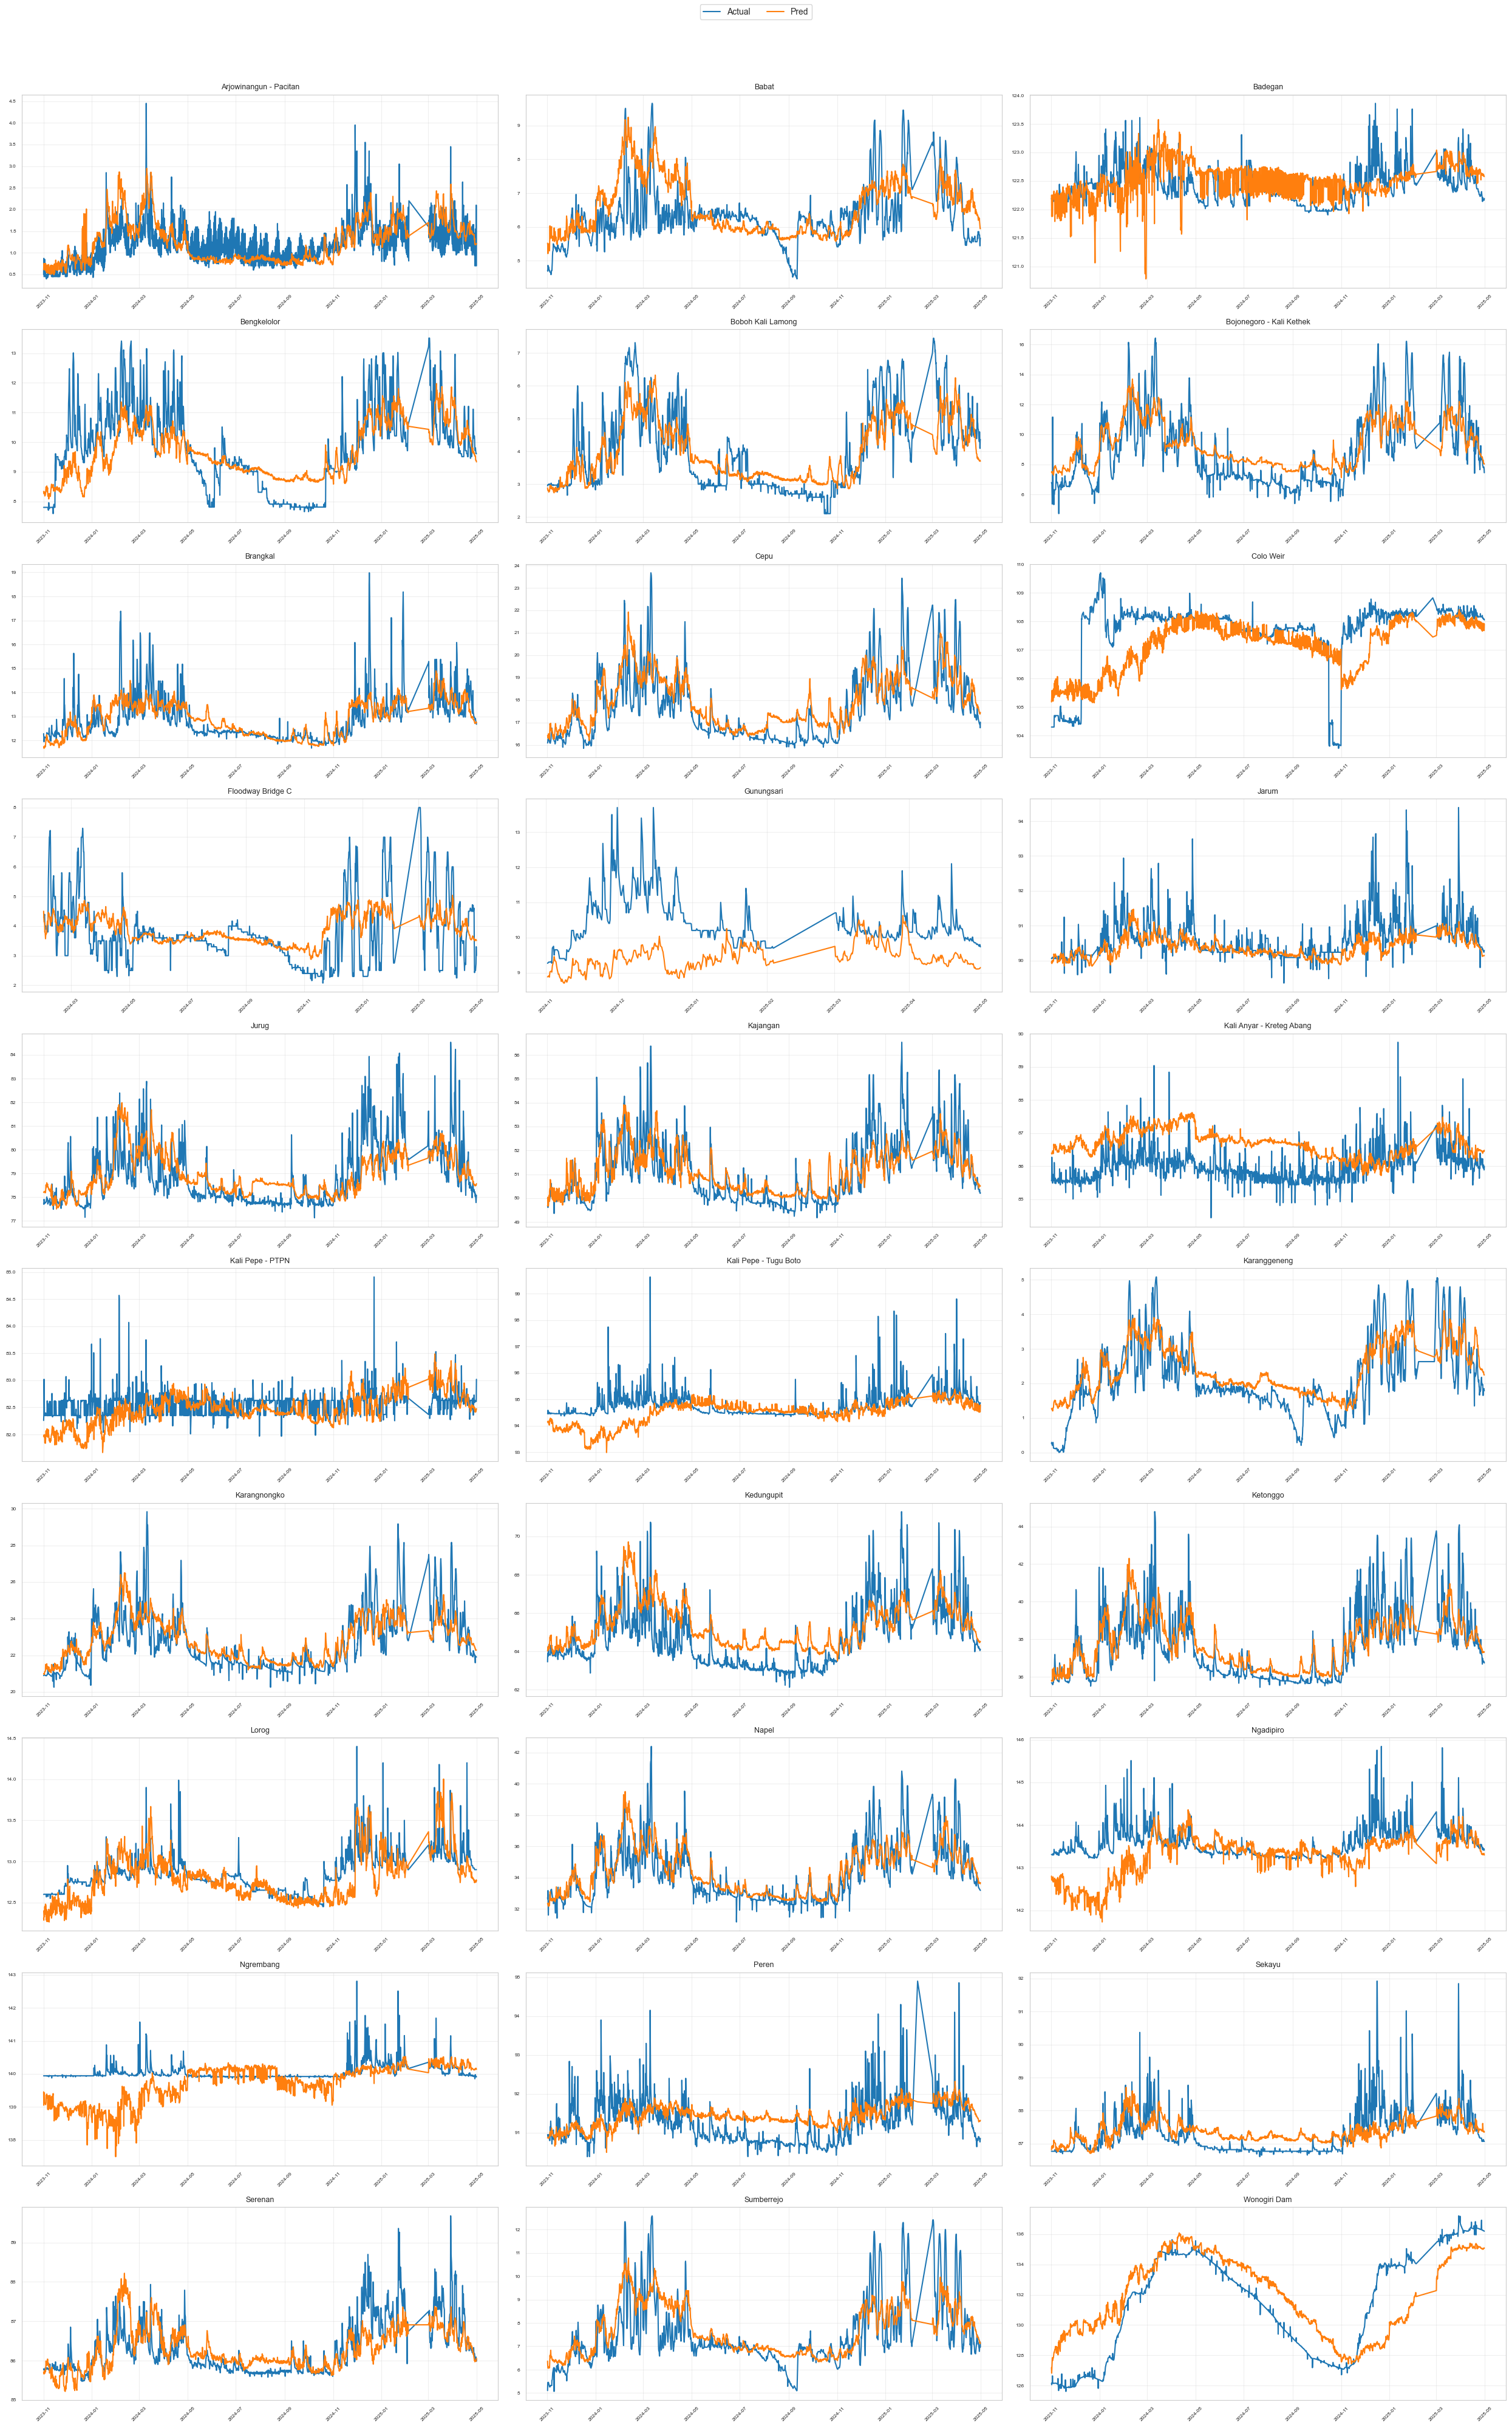

In [108]:
stations = sorted(pred_df["nama_pos"].unique())

ncols = 3      # ubah ke 5 kalau mau 5 per baris
nrows = math.ceil(len(stations) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(25, 4*nrows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    df_plot = (
        pred_df[pred_df["nama_pos"] == station]
        .sort_values("datetime")
    )

    ax.plot(
        df_plot["datetime"],
        df_plot["tma_mdpl"],
        color="tab:blue",
        linewidth=1.5,
        label="Actual"
    )

    ax.plot(
        df_plot["datetime"],
        df_plot["pred"],
        color="tab:orange",
        linewidth=1.5,
        label="Pred"
    )

    ax.set_title(station, fontsize=9)
    ax.tick_params(axis='x', labelrotation=45, labelsize=6)
    ax.tick_params(axis='y', labelsize=6)
    ax.grid(alpha=0.3)

# Hapus subplot kosong
for j in range(len(stations), len(axes)):
    fig.delaxes(axes[j])

# Legend cukup sekali
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

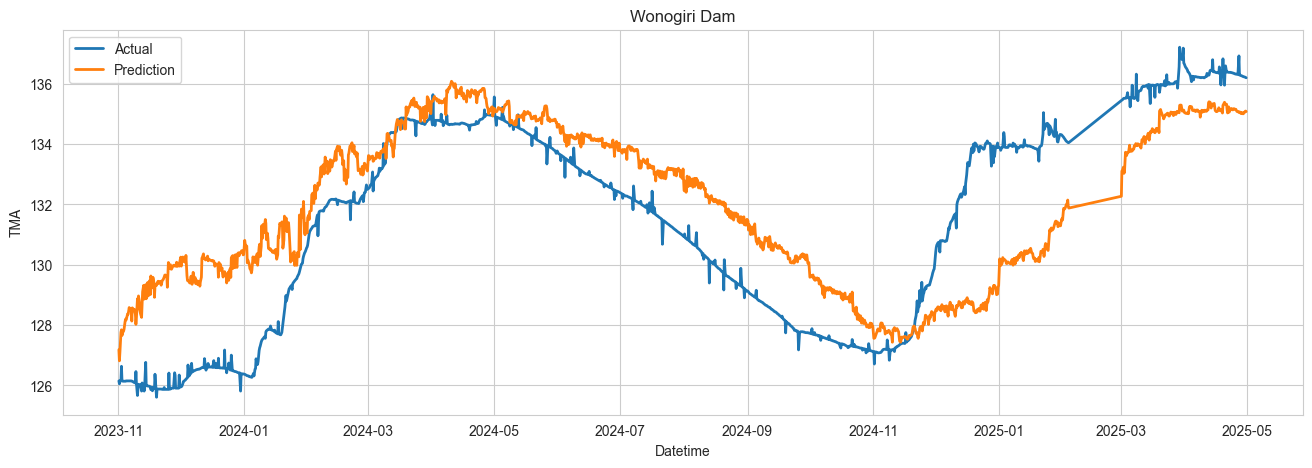

In [109]:
station = "Wonogiri Dam"

plot_df = pred_df[pred_df["nama_pos"] == station].sort_values("datetime")

plt.figure(figsize=(16,5))

plt.plot(
    plot_df["datetime"],
    plot_df["tma_mdpl"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_df["datetime"],
    plot_df["pred"],
    label="Prediction",
    linewidth=2
)

plt.title(station)
plt.xlabel("Datetime")
plt.ylabel("TMA")
plt.legend()
plt.grid(True)

plt.show()

## Feature Importance

In [110]:
# ===== training ketiga model (single split, spt biasa) =====
sample_weight_cat = np.where(train_set['musim_hujan']==1, 2.4, 1.0)
sample_weight_xgb = np.where(train_set['musim_hujan']==1, 10, 1.0)
sample_weight_lgbm = np.where(train_set['musim_hujan']==1, 8.2, 1.0)

cat = CatBoostRegressor(**cat_params)
cat.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_cat)

xgb = XGBRegressor(**xgb_params)
xgb.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_xgb)

lgbm = LGBMRegressor(**lgbm_params)
lgbm.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_lgbm)

# ===== ambil feature importance -- CATATAN: nama attribute BEDA tiap library =====
imp_cat  = pd.Series(cat.get_feature_importance(), index=feature_cols, name='CatBoost')
imp_xgb  = pd.Series(xgb.feature_importances_, index=feature_cols, name='XGBoost')
imp_lgbm = pd.Series(lgbm.feature_importances_, index=feature_cols, name='LightGBM')

# ===== normalisasi ke skala 0-100% biar bisa dibandingkan apple-to-apple =====
imp_cat_pct  = imp_cat / imp_cat.sum() * 100
imp_xgb_pct  = imp_xgb / imp_xgb.sum() * 100
imp_lgbm_pct = imp_lgbm / imp_lgbm.sum() * 100

importance_compare = pd.concat([imp_cat_pct, imp_xgb_pct, imp_lgbm_pct], axis=1)
importance_compare['avg'] = importance_compare.mean(axis=1)
importance_compare = importance_compare.sort_values('avg', ascending=False)

print('=== Top 20 fitur, dibandingkan across 3 model (dlm %) ===')
print(importance_compare.head(20).round(2).to_string())

=== Top 20 fitur, dibandingkan across 3 model (dlm %) ===
                      CatBoost    XGBoost  LightGBM    avg
nama_pos_te              21.16  54.740002      0.08  25.33
station_mean_tma_x       13.47  17.840000      2.07  11.12
station_max_tma_y        23.90   0.000000      0.06   7.99
station_max_tma_x         7.72  15.750000      0.31   7.93
station_min_tma_x         4.47  10.960000      0.73   5.39
station_min_tma_y        10.30   0.000000      0.01   3.44
station_mean_tma_y        8.31   0.000000      0.01   2.77
station_cluster_x         3.90   0.000000      0.36   1.42
rain_14d_x_upstream       0.11   0.000000      2.76   0.96
built_surface_m2          0.68   0.180000      1.72   0.86
rain_7d_x_upstream        0.01   0.000000      2.04   0.68
latitude_x                0.19   0.050000      1.75   0.66
rain_48h_x_upstream       0.02   0.000000      1.86   0.63
rain_cumsum_336h          0.00   0.000000      1.82   0.61
rmm2_roll_mean_120        0.00   0.000000      1.80   0.6

In [111]:
# fitur yg importance-nya BEDA JAUH antar model = sinyal model2 ini "melihat" data dgn cara beda
importance_compare['spread'] = importance_compare[['CatBoost','XGBoost','LightGBM']].std(axis=1)
print('\n=== Fitur dgn perbedaan pandangan PALING BESAR antar model ===')
print(importance_compare.sort_values('spread', ascending=False).head(15).round(2).to_string())


=== Fitur dgn perbedaan pandangan PALING BESAR antar model ===
                     CatBoost    XGBoost  LightGBM    avg  spread
nama_pos_te             21.16  54.740002      0.08  25.33   27.57
station_max_tma_y       23.90   0.000000      0.06   7.99   13.78
station_mean_tma_x      13.47  17.840000      2.07  11.12    8.14
station_max_tma_x        7.72  15.750000      0.31   7.93    7.73
station_min_tma_y       10.30   0.000000      0.01   3.44    5.94
station_min_tma_x        4.47  10.960000      0.73   5.39    5.18
station_mean_tma_y       8.31   0.000000      0.01   2.77    4.80
station_cluster_x        3.90   0.000000      0.36   1.42    2.15
rain_14d_x_upstream      0.11   0.000000      2.76   0.96    1.56
rain_7d_x_upstream       0.01   0.000000      2.04   0.68    1.17
rain_48h_x_upstream      0.02   0.000000      1.86   0.63    1.07
rain_cumsum_336h         0.00   0.000000      1.82   0.61    1.05
rmm2_roll_mean_120       0.00   0.000000      1.80   0.60    1.04
latitude_x  

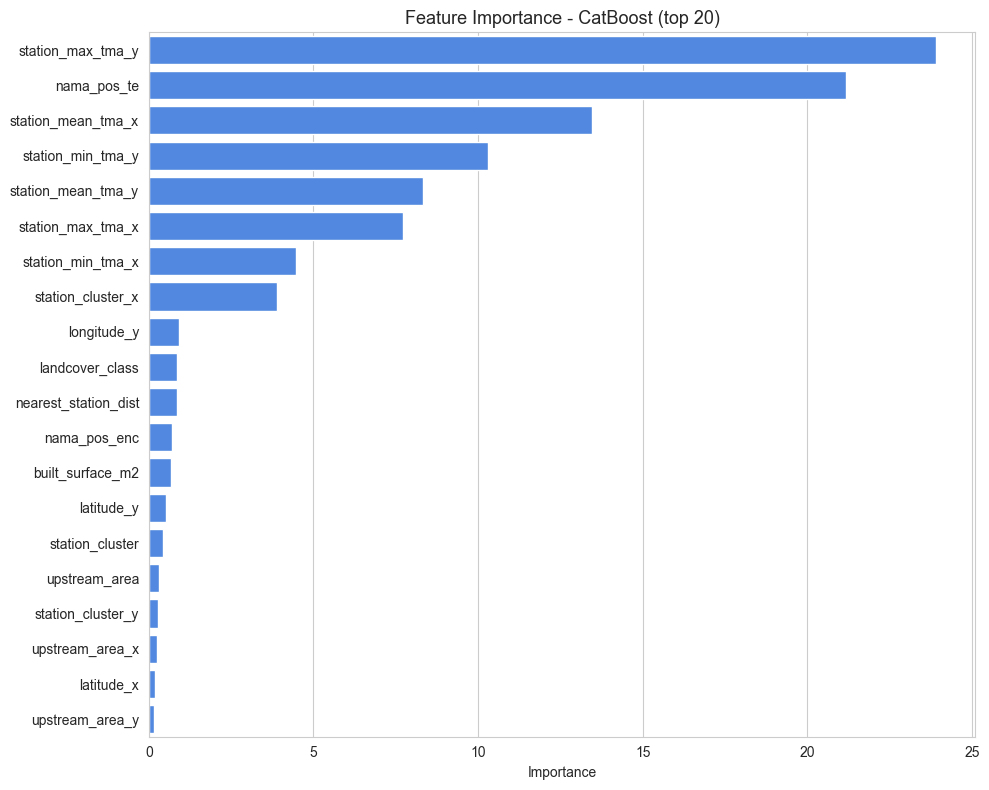

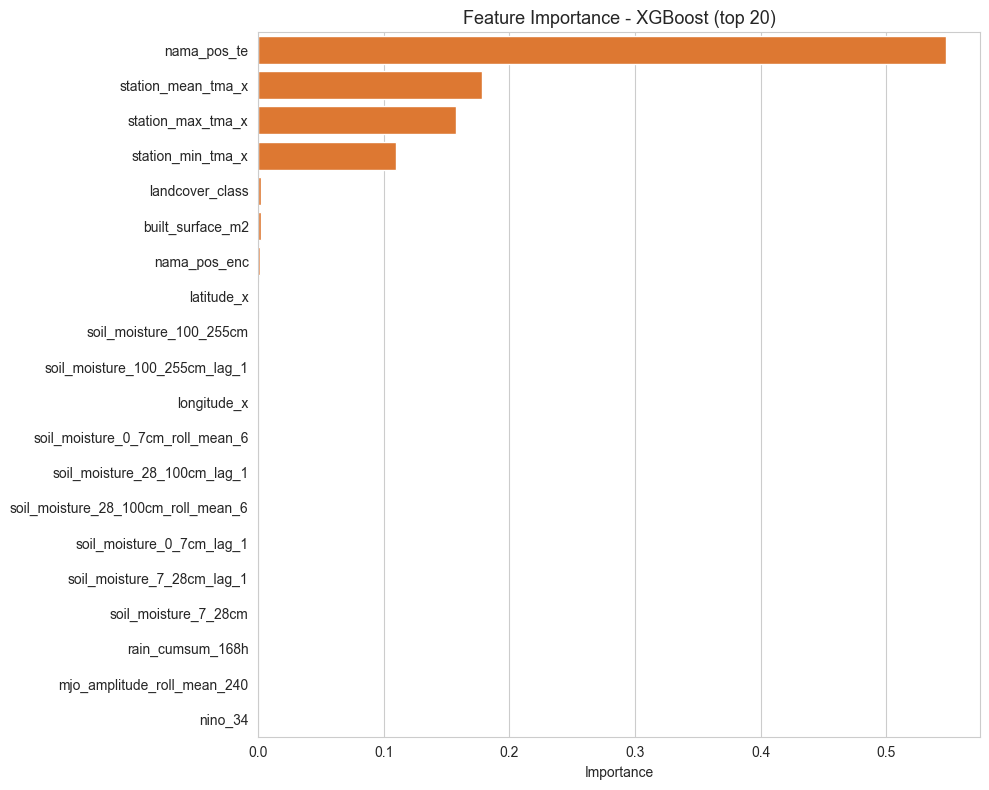

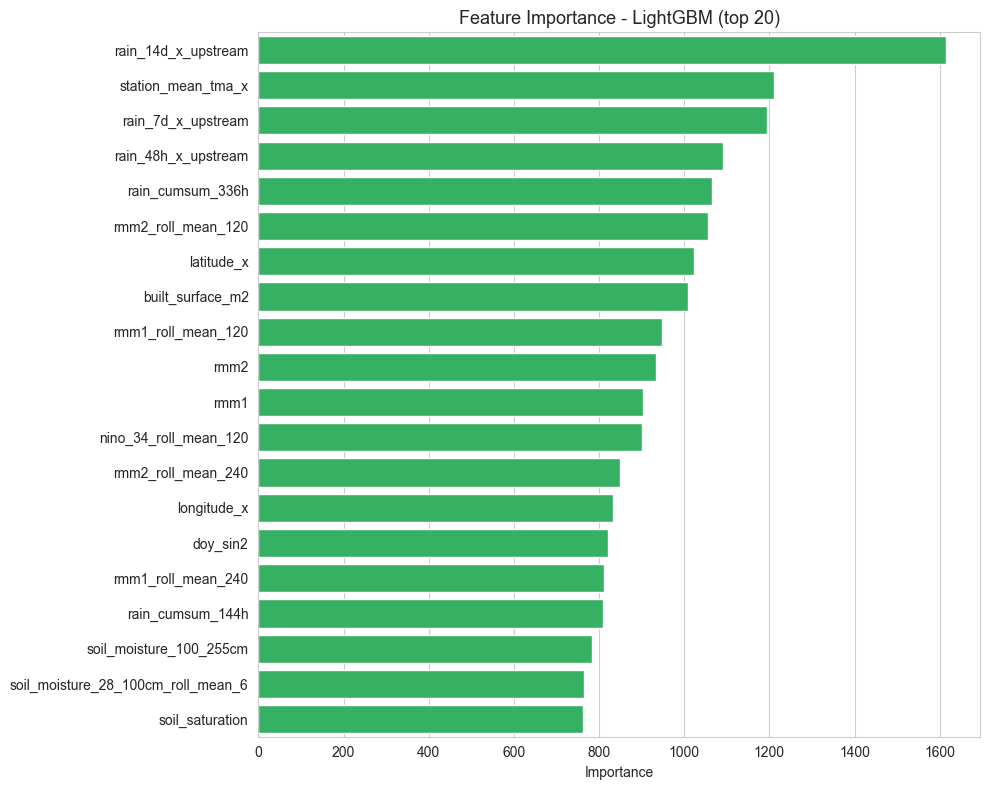

In [112]:
sns.set_style('whitegrid')

# ===== ambil feature importance -- attribute beda tiap library =====
imp_cat  = pd.Series(cat.get_feature_importance(), index=feature_cols, name='importance')
imp_xgb  = pd.Series(xgb.feature_importances_, index=feature_cols, name='importance')
imp_lgbm = pd.Series(lgbm.feature_importances_, index=feature_cols, name='importance')

# ===== plot masing-masing TERPISAH, top 20 fitur per model =====
def plot_importance(imp_series, model_name, top_n=20,color="black"):
    df_imp = imp_series.sort_values(ascending=False).head(top_n).reset_index()
    df_imp.columns = ['feature', 'importance']

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=df_imp, y='feature', x='importance', color=color, ax=ax)
    ax.set_title(f'Feature Importance - {model_name} (top {top_n})', fontsize=13)
    ax.set_xlabel('Importance')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

plot_importance(imp_cat, 'CatBoost', top_n=20, color='#3b82f6')
plot_importance(imp_xgb, 'XGBoost', top_n=20, color='#f97316')
plot_importance(imp_lgbm, 'LightGBM', top_n=20, color='#22c55e')

In [113]:
val_set = val_set.copy()
val_set['pred'] = cat.predict(val_set[feature_cols])  # ganti 'cat' sesuai model kamu

# RMSE per pos + NRMSE (dinormalisasi thd rentang tma pos itu sendiri, biar ADIL lintas skala)
per_pos = val_set.groupby('nama_pos').apply(
    lambda d: pd.Series({
        'rmse': np.sqrt(mean_squared_error(d['tma_mdpl'], d['pred'])),
        'tma_range': train_set[train_set['nama_pos']==d.name]['tma_mdpl'].max() - train_set[train_set['nama_pos']==d.name]['tma_mdpl'].min(),
        'n_baris': len(d),
    })
).reset_index()
per_pos['nrmse_pct'] = (per_pos['rmse'] / per_pos['tma_range']) * 100
per_pos = per_pos.sort_values('nrmse_pct', ascending=False)

print('=== 10 pos TERBURUK (NRMSE %, adil lintas skala) ===')
print(per_pos.head(10).to_string(index=False))
print()
print('=== 10 pos TERBAIK ===')
print(per_pos.tail(10).to_string(index=False))

=== 10 pos TERBURUK (NRMSE %, adil lintas skala) ===
                nama_pos     rmse  tma_range  n_baris  nrmse_pct
       Boboh Kali Lamong 1.198035   5.500000    600.0  21.782446
       Floodway Bridge C 1.051585   5.924736    600.0  17.749065
                 Badegan 0.329005   2.057899    600.0  15.987425
            Wonogiri Dam 1.658513  11.710459    600.0  14.162662
             Bengkelolor 0.816150   5.934234    600.0  13.753243
                   Babat 0.656994   5.250000    586.0  12.514164
                   Lorog 0.289224   2.350000    600.0  12.307388
              Gunungsari 0.575759   4.682803    600.0  12.295172
            Karanggeneng 0.613883   5.080000    600.0  12.084316
Bojonegoro - Kali Kethek 1.332927  11.687227    593.0  11.404992

=== 10 pos TERBAIK ===
                 nama_pos     rmse  tma_range  n_baris  nrmse_pct
                Colo Weir 0.616689   7.513668    600.0   8.207569
Kali Anyar - Kreteg Abang 0.427482   5.299511    600.0   8.066445
          

C:\Users\leouw\AppData\Local\Temp\ipykernel_11056\3487094808.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pos = val_set.groupby('nama_pos').apply(


In [114]:
per_pos['total_se'] = per_pos['rmse']**2 * per_pos['n_baris']
per_pos['pct_of_total_se'] = per_pos['total_se'] / per_pos['total_se'].sum() * 100
per_pos_by_impact = per_pos.sort_values('total_se', ascending=False)

print('=== Ranking berdasar KONTRIBUSI ke skor leaderboard ===')
print(per_pos_by_impact[['nama_pos','rmse','n_baris','total_se','pct_of_total_se']].head(10).to_string(index=False))
print(f'\n10 pos teratas ini menyumbang: {per_pos_by_impact.head(10)["pct_of_total_se"].sum():.1f}% dari total error')

=== Ranking berdasar KONTRIBUSI ke skor leaderboard ===
                nama_pos     rmse  n_baris    total_se  pct_of_total_se
            Wonogiri Dam 1.658513    600.0 1650.398764        15.972896
Bojonegoro - Kali Kethek 1.332927    593.0 1053.580211        10.196765
       Boboh Kali Lamong 1.198035    600.0  861.172016         8.334599
       Floodway Bridge C 1.051585    600.0  663.498800         6.421477
                Ketonggo 0.964915    600.0  558.636227         5.406596
                   Napel 0.941245    600.0  531.565050         5.144595
            Karangnongko 0.932151    600.0  521.343227         5.045666
              Kedungupit 0.843064    600.0  426.454180         4.127311
             Bengkelolor 0.816150    600.0  399.660196         3.867993
                    Cepu 0.802922    598.0  385.521334         3.731154

10 pos teratas ini menyumbang: 68.2% dari total error


# Submission

In [115]:
sample_weight_tr = np.where(train['musim_hujan']==1, 2.4, 1.0)

lookup_map_fold = train.set_index(['nama_pos','datetime'])['tma_mdpl'].to_dict() 
value_fn_fold = lambda pos, t, lm=lookup_map_fold: lm.get((pos, t), np.nan)

train = add_upstream_feature(train, pairs_calibrated, value_fn_fold)

train = add_decayed_persistence(train, train, decay_days=90, is_training=True)
cat_final = CatBoostRegressor(**cat_params); cat_final.fit(train[feature_cols], train['tma_mdpl'], sample_weight=sample_weight_tr)
# xgb_final = XGBRegressor(**xgb_params); xgb_final.fit(train[feature_cols], train['tma_mdpl'])
# lgbm_final = LGBMRegressor(**lgbm_params); lgbm_final.fit(train[feature_cols], train['tma_mdpl'])

CatBoostRegressor(colsample_bylevel=0.8, depth=6, iterations=300, learning_rate=0.04, loss_function='RMSE', random_state=42, subsample=0.8, verbose=False)

## XGB

In [116]:
# test_pred = xgb_final.predict(test[feature_cols])
# submit_xgb = pd.DataFrame({'id': test['id'], 'tma_mdpl': test_pred})
# submit_xgb.to_csv('outputs/submission_xgb.csv', index=False)

## LGBM

In [117]:
# test_pred = lgbm_final.predict(test[feature_cols])
# submit_lgbm = pd.DataFrame({'id': test['id'], 'tma_mdpl': test_pred})
# submit_lgbm.to_csv('outputs/submission_lgbm.csv', index=False)

## CatBoost

In [120]:


# feature_cols = [c for c in train.columns if c not in non_feature]
# # extra_feats = ['decayed_persistence']
# extra_feats = ['upstream_tma', 'decayed_persistence']
# # extra_feats = ['upstream_tma']
# feature_cols += [f for f in extra_feats if f not in feature_cols]


test_pred = cat_final.predict(test[feature_cols])
submit_cat = pd.DataFrame({'id': test['id'], 'tma_mdpl': test_pred})
submit_cat.to_csv('outputs/submission_cat.csv', index=False)

## Ensemble Voting

In [119]:
# pred_cat_test = cat_final.predict(test[feature_cols])
# pred_xgb_test = xgb_final.predict(test[feature_cols])
# pred_lgbm_test = lgbm_final.predict(test[feature_cols])

# final_pred = (best_weights[0]*pred_cat_test + best_weights[1]*pred_xgb_test + best_weights[2]*pred_lgbm_test)

# submit_ensemble = pd.DataFrame({'id': test['id'], 'tma_mdpl': final_pred})
# submit_ensemble.to_csv('outputs/submission_ensemble.csv', index=False)